In [2]:
!pip install pandas numpy matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 92.8 MB/s eta 0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 81.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 93.7 MB/s eta 0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
print("🚀 Análise Olist - Limpeza e EDA")

🚀 Análise Olist - Limpeza e EDA


In [5]:
# 1. Carregando os arquivos
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

print(f"📊 Orders: {orders.shape}")
print(f"📦 Order Items: {order_items.shape}")
print(f"📱 Products: {products.shape}")

📊 Orders: (99441, 8)
📦 Order Items: (112650, 7)
📱 Products: (32951, 9)


In [6]:
# 2. Limpeza dos dados
print("\n🧹 Limpando...")
# Datas
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
# Nulos products
products['product_category_name'] = products['product_category_name'].fillna('sem_categoria')


🧹 Limpando...


In [7]:
# 3. JOIN
df = order_items.merge(products[['product_id','product_category_name']], on='product_id')
print(f"✅ Dataset pronto: {df.shape}")

# 4. TOP CATEGORIAS (para estoque!)
top_cats = df['product_category_name'].value_counts().head(10)
print("\n🏆 TOP 10 CATEGORIAS:")
print(top_cats)

✅ Dataset pronto: (112650, 8)

🏆 TOP 10 CATEGORIAS:
product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64


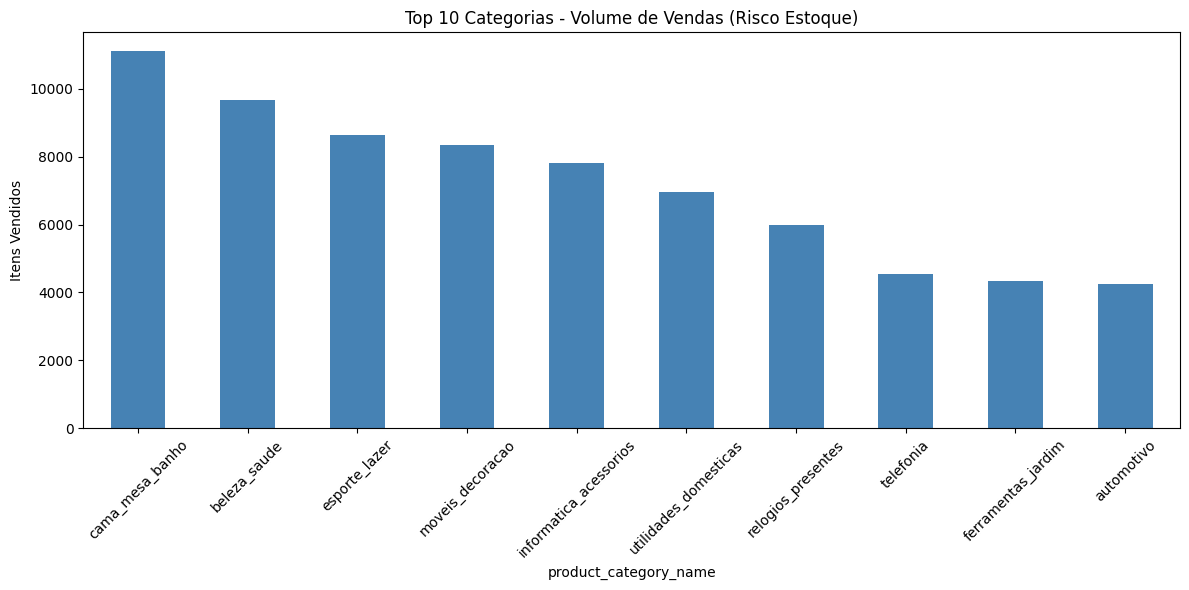

✅ Gráfico salvo: top_categorias.png
✅ PRONTO PARA RELATÓRIO!


In [8]:
# 5. Criando Gráfico
plt.figure(figsize=(12,6))
top_cats.plot(kind='bar', color='steelblue')
plt.title('Top 10 Categorias - Volume de Vendas (Risco Estoque)')
plt.ylabel('Itens Vendidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_categorias.png', dpi=300)
plt.show()

print("✅ Gráfico salvo: top_categorias.png")
print("✅ PRONTO PARA RELATÓRIO!")

In [9]:
# Tabela 1: Volume e ticket por categoria
tabela1 = (
    df.groupby('product_category_name')
    .agg({
        'order_id': ['count', 'nunique'],  # volume itens, pedidos únicos
        'price': 'mean'                    # ticket médio
    })
    .round(2)
    .reset_index()
)
tabela1.columns = ['categoria', 'volume_itens', 'n_pedidos', 'ticket_medio']
tabela1['ticket_medio'] = tabela1['ticket_medio'].round(2)

In [10]:
# Tabela 2: Volatilidade (desvio padrão / média)
tabela2 = df.groupby('product_category_name')['price'].agg(['std', 'mean']).reset_index()
tabela2['volatilidade_cv'] = (tabela2['std'] / tabela2['mean']).round(3)
tabela2 = tabela2[['product_category_name', 'volatilidade_cv']]


In [12]:
# Juntar tudo em 1 tabela final
dados_looker = tabela1.merge(tabela2, left_on='categoria', right_on='product_category_name')
dados_looker.drop('product_category_name', axis=1, inplace=True)

In [13]:
# Classificar risco (simples)
dados_looker['risco'] = np.where(
    (dados_looker['volatilidade_cv'] > 0.6) | (dados_looker['volume_itens'] > 5000),
    '🔴 Alto',
    np.where(dados_looker['volatilidade_cv'] > 0.4, '🟠 Médio', '🟢 Baixo')
)

In [14]:
# Top 20 categorias
dados_looker = dados_looker.nlargest(20, 'volume_itens')

In [15]:
# SALVAR CSV FINAL
dados_looker.to_csv('dados_looker_dashboard.csv', index=False)


In [16]:
print("✅ TABELAS CRIADAS E EXPORTADAS!")
print("\n📋 Preview (top 5):")
print(dados_looker.head())

print("\n📁 Arquivo pronto: 'dados_looker_dashboard.csv'")
print("Colunas: categoria | volume_itens | n_pedidos | ticket_medio | volatilidade_cv | risco")

✅ TABELAS CRIADAS E EXPORTADAS!

📋 Preview (top 5):
                 categoria  volume_itens  n_pedidos  ticket_medio  \
13         cama_mesa_banho         11115       9417         93.30   
11            beleza_saude          9670       8836        130.16   
32           esporte_lazer          8641       7720        114.34   
54        moveis_decoracao          8334       6449         87.56   
44  informatica_acessorios          7827       6689        116.51   

    volatilidade_cv   risco  
13            0.880  🔴 Alto  
11            1.379  🔴 Alto  
32            1.421  🔴 Alto  
54            1.014  🔴 Alto  
44            1.459  🔴 Alto  

📁 Arquivo pronto: 'dados_looker_dashboard.csv'
Colunas: categoria | volume_itens | n_pedidos | ticket_medio | volatilidade_cv | risco
